## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, extract_cnn_feature_maps, pca_on_channels
from src.preprocessing.dataset import ChessSquareDataset, ChessBoardDataset
from src.utils.dataset_utils import get_dataset_stats, build_transforms, get_square_by_class, calculate_stats
from src.utils.plotting import visualize_test_samples, plot_training_history, plot_class_distribution, plot_feature_maps
from src.constants import CLASS_MAP
from tqdm.notebook import tqdm
from collections import Counter
import numpy as np

In [3]:
# Load data

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_SYNTHETIC_DATA_ROOT = os.path.join(project_root, "data/test/synthetic") 
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, NUM_WORKERS)

# Build Final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform)
train_square_dataset = ChessSquareDataset(train_dataset)
test_synthetic_dataset = ChessBoardDataset(root_dir=TEST_SYNTHETIC_DATA_ROOT, transform=train_transform)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform)

test_synthetic_loader = DataLoader(test_synthetic_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1125 | Test samples: 132
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 5/5 [00:13<00:00,  2.78s/it]



Calculated training mean: [0.5405116677284241, 0.5397956371307373, 0.5381444692611694]
Calculated training std:  [0.10387232899665833, 0.10447882860898972, 0.10541636496782303]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 1/1 [00:03<00:00,  3.45s/it]



Calculated test mean: [0.6565031409263611, 0.6223108768463135, 0.5438199639320374]
Calculated test std:  [0.14106103777885437, 0.14781025052070618, 0.13531261682510376]

Pre-loading dataset...


100%|██████████| 1125/1125 [00:34<00:00, 32.17it/s]


In [6]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [7]:
import random


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [8]:
padding_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.5]

results = {}

print("Starting Padding Experiment...")

for p in padding_values:
    print(f"\n" + "="*40)
    print(f"Testing Padding Factor: {p}")
    print("="*40)
    
    # Initialize datasets with new padding
    train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=p)
    val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=test_transform, padding=p)
    # train_square_dataset = ChessSquareDataset(train_dataset)

    # # Calculate weights for weighted loss and sampler
    # target_list = train_square_dataset.labels
    # class_counts = np.bincount(target_list)
    # total_samples = sum(class_counts)
    # num_classes = len(class_counts)
    # normalized_weights = [total_samples / (num_classes * c) for c in class_counts]
    # class_weights = torch.tensor(normalized_weights).float().to(device)
    # sampler_weights = 1. / class_counts
    # samples_weights = torch.tensor([sampler_weights[t] for t in target_list])

    set_seed()
    
    # # Create sampler
    # sampler = WeightedRandomSampler(
    #     weights=samples_weights,
    #     num_samples=len(samples_weights),
    #     replacement=True
    # )
    
    # # Initialize loaders 
    # train_loader = DataLoader(train_square_dataset, sampler=sampler, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    # val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    # Initialize loaders 
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
    # Initialize model
    model = get_baseline_model().to(device)

    # Training configuration
    lr = 1e-4
    num_epochs = 12
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop 
    model, history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=None,
        num_epochs=num_epochs,
        device=device,
        save_path=os.path.join(project_root, f'models/baseline_wl_p{p}.pth')
    )

    square_acc, board_acc = evaluate(model, test_real_loader, device)
                
    results[p] = square_acc
    print(f"--> Test Accuracy for padding {p}: {square_acc:.2f}%")

print("\nFinal Padding Experiment Results:", results)

Starting Padding Experiment...

Testing Padding Factor: 0.0
Training on cuda for 12 epochs...


Training Progress:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/12 | Train: Loss=0.0427 Acc=0.9902  Val: Loss=0.0442 Acc=0.9882   [Saved Best]
Epoch 2/12 | Train: Loss=0.0008 Acc=1.0000  Val: Loss=0.0314 Acc=0.9909   [Saved Best]
Epoch 3/12 | Train: Loss=0.0004 Acc=1.0000  Val: Loss=0.0269 Acc=0.9918   [Saved Best]
Epoch 4/12 | Train: Loss=0.0070 Acc=0.9982  Val: Loss=0.0296 Acc=0.9948   [Saved Best]
Epoch 5/12 | Train: Loss=0.0006 Acc=0.9999  Val: Loss=0.0064 Acc=0.9986   [Saved Best]
Epoch 6/12 | Train: Loss=0.0002 Acc=1.0000  Val: Loss=0.0083 Acc=0.9972  
Epoch 7/12 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0069 Acc=0.9972  
Epoch 8/12 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0033 Acc=0.9979  
Epoch 9/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0066 Acc=0.9977  
Epoch 10/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0034 Acc=0.9978  
Epoch 11/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0071 Acc=0.9976  
Epoch 12/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.0047 Acc=0.9977  

Training complete in 4m 16s
Best Val Acc: 0

Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

--> Test Accuracy for padding 0.0: 64.88%

Testing Padding Factor: 0.2
Training on cuda for 12 epochs...


...

--> Test Accuracy for padding 1.2: 63.04%

Testing Padding Factor: 1.5
Training on cuda for 12 epochs...


Training Progress:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/12 | Train: Loss=0.1012 Acc=0.9737  Val: Loss=0.7823 Acc=0.7645   [Saved Best]
Epoch 2/12 | Train: Loss=0.0062 Acc=0.9986  Val: Loss=0.5713 Acc=0.8248   [Saved Best]
Epoch 3/12 | Train: Loss=0.0046 Acc=0.9990  Val: Loss=0.4742 Acc=0.8634   [Saved Best]
Epoch 4/12 | Train: Loss=0.0033 Acc=0.9992  Val: Loss=0.3506 Acc=0.8924   [Saved Best]
Epoch 5/12 | Train: Loss=0.0051 Acc=0.9988  Val: Loss=0.2368 Acc=0.9317   [Saved Best]
Epoch 6/12 | Train: Loss=0.0021 Acc=0.9995  Val: Loss=0.4020 Acc=0.8875  
Epoch 7/12 | Train: Loss=0.0053 Acc=0.9985  Val: Loss=0.1917 Acc=0.9310  
Epoch 8/12 | Train: Loss=0.0002 Acc=1.0000  Val: Loss=0.1791 Acc=0.9453   [Saved Best]
Epoch 9/12 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.1498 Acc=0.9504   [Saved Best]
Epoch 10/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.1957 Acc=0.9414  
Epoch 11/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.1545 Acc=0.9515   [Saved Best]
Epoch 12/12 | Train: Loss=0.0000 Acc=1.0000  Val: Loss=0.1674 Acc=0.9479  

Trai

Evaluating:   0%|          | 0/66 [00:00<?, ?it/s]

--> Test Accuracy for padding 1.5: 62.84%

Final Padding Experiment Results: {0.0: 64.87926136363636, 0.2: 61.64772727272727, 0.4: 63.10369318181818, 0.6: 63.293087121212125, 0.8: 62.97348484848485, 1: 62.61837121212121, 1.2: 63.04450757575758, 1.5: 62.843276515151516}


In [55]:
best_model = torch.load(os.path.join(project_root, 'models/baseline_wl_p0.0.pth'))

/tmp/ipykernel_1230603/2454372905.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model = torch.load(os.path.join(project_root, 'models/baseline_wl_p0.0.pth'))


Accuracy per Class:

white_pawn: 1.20% (11/914 correct)
white_rook: 66.98% (144/215 correct)
white_knight: 0.00% (0/142 correct)
white_bishop: 0.00% (0/164 correct)
white_queen: 0.00% (0/95 correct)
white_king: 7.58% (10/132 correct)
black_pawn: 2.53% (23/908 correct)
black_rook: 29.49% (69/234 correct)
black_knight: 0.00% (0/138 correct)
black_bishop: 5.81% (9/155 correct)
black_queen: 10.64% (10/94 correct)
black_king: 0.76% (1/132 correct)
empty     : 99.67% (5108/5125 correct)




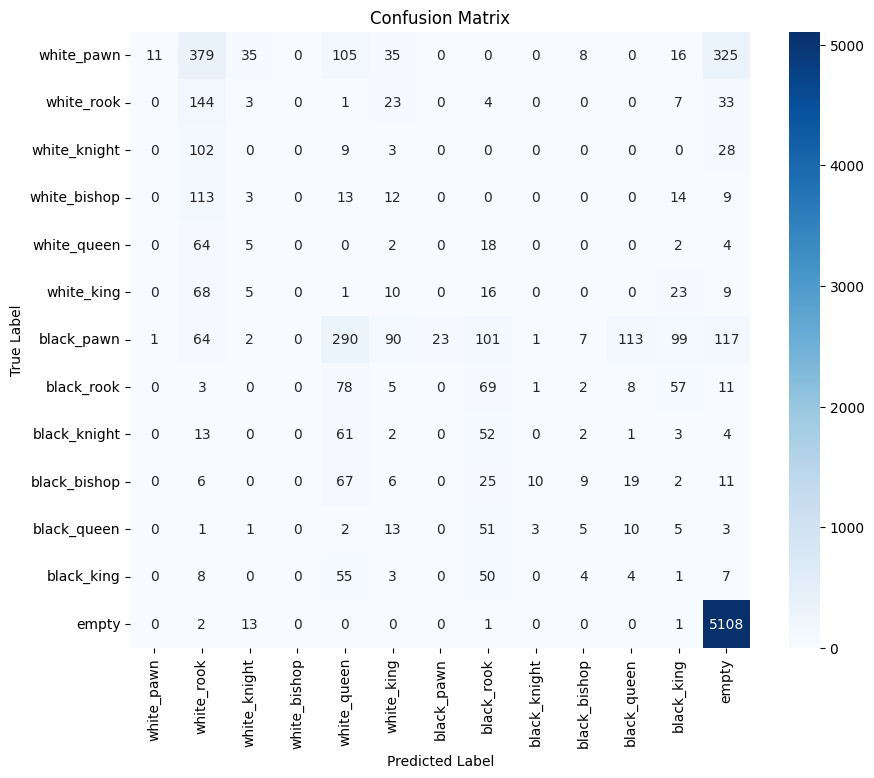

In [56]:
class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance(best_model, test_real_loader, class_names, device)

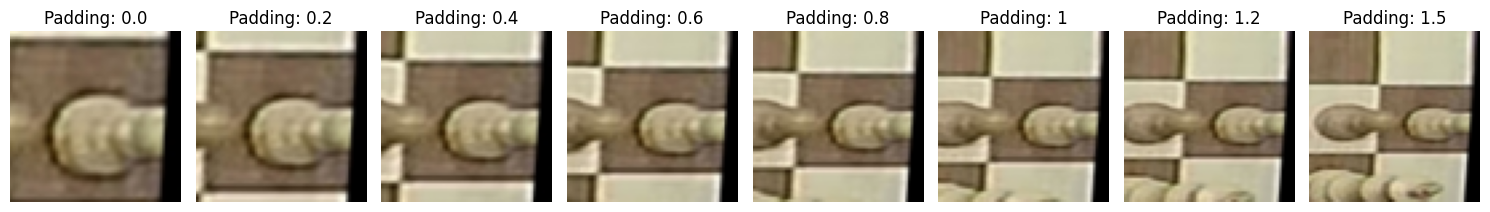

In [19]:
import cv2

viz_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

padding_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.5]
    
plt.figure(figsize=(15, 5))

for i, p in enumerate(padding_values):
    ds = ChessBoardDataset(TEST_REAL_DATA_ROOT, transform=viz_transform, padding=p)

    square_idx = 55

    img, label = ds[0]
    img = img[square_idx]
    
    plt.subplot(1, len(padding_values), i+1)
    
    # Convert to numpy for plotting if it's a Tensor
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()
        
    plt.imshow(img)
    plt.title(f"Padding: {p}")
    plt.axis('off')

plt.tight_layout()
plt.show()